# **Imports**

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import os

# **Read Dataset**

In [63]:
# Reading the CSV file
BASE = os.getcwd()

DATASETS_DIR = os.path.join(BASE, "datasets")
DATASET_FILE = "NSSO68.csv"
DATASET_PATH = os.path.join(DATASETS_DIR, DATASET_FILE)

df = pd.read_csv(DATASET_PATH, low_memory=False)

In [64]:
df.head()

,slno,grp,Round_Centre,FSU_number,Round,Schedule_Number,Sample,Sector,state,State_Region,...,pickle_v,sauce_jam_v,Othrprocessed_v,Beveragestotal_v,foodtotal_v,foodtotal_q,state_1,Region,fruits_df_tt_v,fv_tot
0,1,4.10E+31,1,41000,68,10,1,2,24,242,...,0.0,0.0,0.0,0.000000,1141.492400,30.942394,GUJ,2,12.000000,154.18
1,2,4.10E+31,1,41000,68,10,1,2,24,242,...,0.0,0.0,0.0,17.500000,1244.553500,29.286153,GUJ,2,333.000000,484.95
2,3,4.10E+31,1,41000,68,10,1,2,24,242,...,0.0,0.0,0.0,0.000000,1050.315400,31.527046,GUJ,2,35.000000,214.84
3,4,4.10E+31,1,41000,68,10,1,2,24,242,...,0.0,0.0,0.0,33.333333,1142.591667,27.834607,GUJ,2,168.333333,302.30
4,5,4.10E+31,1,41000,68,10,1,2,24,242,...,0.0,0.0,0.0,75.000000,945.249500,27.600713,GUJ,2,15.000000,148.00


In [65]:
# Filtering for Meghalaya Data
print((df['state'] == 17).sum())

1259


In [66]:
meg_df = df[df['state'] == 17].copy()

# **Plot Histogram of Food Consumption in Meghalaya**

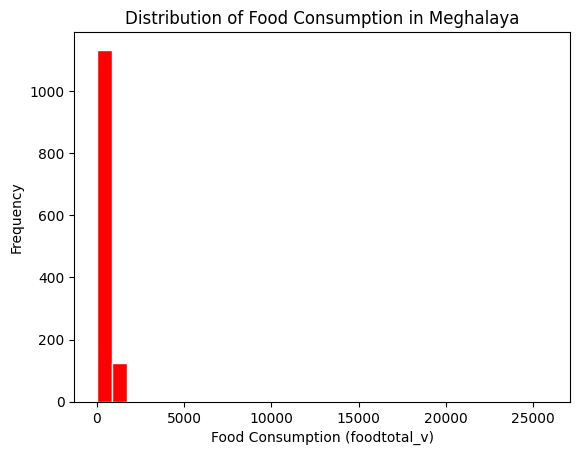

In [67]:
plt.hist(meg_df['foodtotal_v'].dropna(), bins=30, color='red', edgecolor='white')
plt.title("Distribution of Food Consumption in Meghalaya")
plt.xlabel("Food Consumption (foodtotal_v)")
plt.ylabel("Frequency")
plt.show()

In [68]:
meg_df['District'] = meg_df['District'].astype(str).str.zfill(2)
meg_df['DWCons'] = meg_df.groupby('District')['foodtotal_v'].transform('mean')

In [69]:
district_map = pd.DataFrame({
    'DistrictCode': [f"{i:02d}" for i in range(1, 8)],
    'DistrictName': [
        "West Garo Hills",
        "East Garo Hills",
        "South Garo Hills",
        "West Khasi Hills",
        "Ribhoi",
        "East Khasi Hills",
        "Jaintia Hills"
    ]
})

In [70]:
meg_df['DistrictCode'] = meg_df['District']
meg_df = meg_df.merge(district_map, on='DistrictCode', how='left')

# **Plot Bar graph for Avg Food Consumption by District**

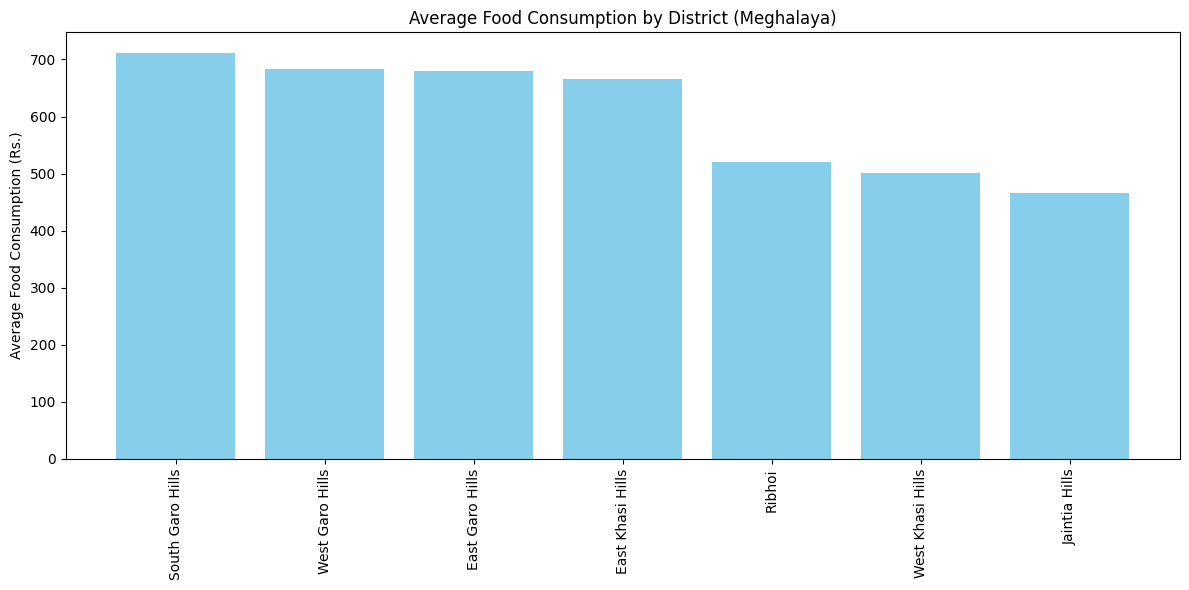

In [71]:
district_avg = meg_df.groupby('DistrictName')['foodtotal_v'].mean().reset_index()
district_avg = district_avg.sort_values(by='foodtotal_v', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(district_avg['DistrictName'], district_avg['foodtotal_v'], color='skyblue')
plt.xticks(rotation=90)
plt.title("Average Food Consumption by District (Meghalaya)")
plt.ylabel("Average Food Consumption (Rs.)")
plt.tight_layout()
plt.show()

# **Display Map of Districts in Meghalaya overlaid with Avg Food Consumption**

['DistrictName', 'stname', 'stcode11', 'dtcode11', 'year_stat', 'Shape_Length', 'Shape_Area', 'OBJECTID', 'test', 'Dist_LGD', 'State_LGD', 'geometry', 'foodtotal_v']


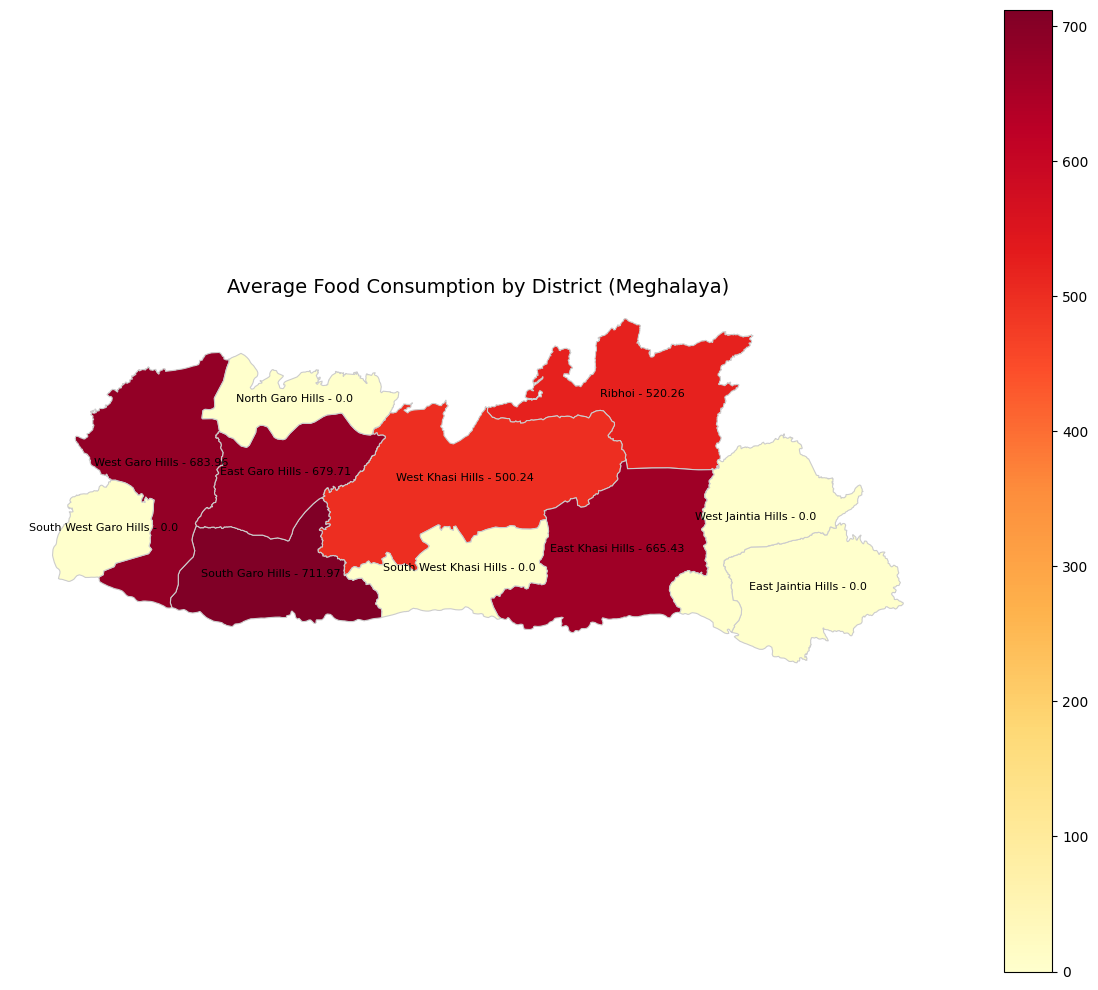

In [ ]:
GEOJSON_FILE = "MEGHALAYA_DISTRICTS.geojson"
GEOJSON_PATH = os.path.join(DATASETS_DIR, GEOJSON_FILE)

# Read GeoJSON file
data_map = gpd.read_file(GEOJSON_PATH)

# Check and rename the district column
data_map = data_map.rename(columns={'dtname': 'DistrictName'})

# Merge geo data with average food data
data_map_data = data_map.merge(district_avg, on='DistrictName', how='left')

print(data_map_data.columns.tolist())

# Fill missing values with 0
data_map_data['foodtotal_v'] = data_map_data['foodtotal_v'].fillna(0)

# Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
data_map_data.plot(column='foodtotal_v',
                   cmap='YlOrRd',
                   linewidth=0.8,
                   ax=ax,
                   edgecolor='0.8',
                   legend=True)

# Add labels
for idx, row in data_map_data.iterrows():
    if row['geometry'].centroid.is_empty:
        continue
    plt.annotate(text='{} - {}'.format(row['DistrictName'], round(row['foodtotal_v'], 2)),
                 xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                 horizontalalignment='center',
                 fontsize=8,
                 color='black')

plt.title("Average Food Consumption by District (Meghalaya)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()